In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn import linear_model
from word2number import w2n

In [2]:
df = pd.read_csv('hiring.csv')

In [3]:
pip install word2number


In [4]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [5]:
df['experience'] = df['experience'].fillna("zero")


In [6]:
df["experience"] = df["experience"].apply(w2n.word_to_num)

In [7]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [8]:
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(df["test_score(out of 10)"].median())

In [9]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


<Axes: >

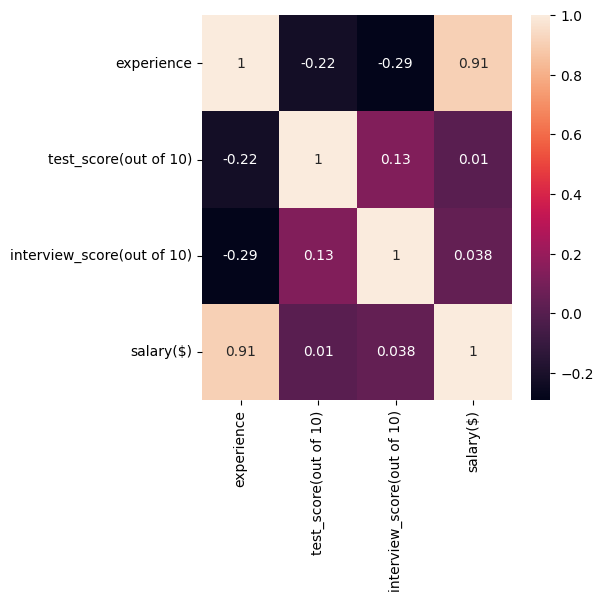

In [10]:
plt.figure(figsize = (5,5))
sns.heatmap(df.corr(), annot = True)

In [11]:
x = df.drop('salary($)', axis = 1)
y = df['salary($)']

In [12]:
model = linear_model.LinearRegression()
model.fit(x,y)

LinearRegression()

In [13]:
model.coef_

array([2812.95487627, 1845.70596798, 2205.24017467])

In [14]:
model.intercept_

np.float64(17737.263464337688)

In [15]:
model.predict([[2, 9, 6]])

array([53205.96797671])

In [16]:
model.predict([[12, 10, 10]])

array([92002.18340611])